WCA

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import optimize
import sympy
import sys
from scipy.optimize import brentq
from scipy.interpolate import InterpolatedUnivariateSpline as uvs

temp = 360# float(sys.argv[1])
ktemp = 0.5922/298.0*temp
beta = 1/ktemp
boxlength = 37.26205 #float(sys.argv[2])
rho_HS = 125/(boxlength**3)

xval=[]
yval=[]
#f =open("./fitting_MeOH_MeOH.table",'r')
f =open("../interaction-tcp/360.table",'r')
i=0
for line in f:
    if i > 0:
        line_e = line.split()
        xval.append(float(line_e[1]))
        yval.append(float(line_e[2]))
    i+=1
spl = uvs(xval,yval,k=5)

/Users/jaehyeok/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/jaehyeok/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (


In [2]:
def get_cavity_function(r, d, eta, verbose=False):
    # Return zeroth and first shell of cavity function
    from numpy import exp, cos, sin
    x = r/d

    # Zeroth shell
    lambda_1 = (1+2*eta)**2/(1-eta)**4
    lambda_2 = -(2+eta)**2/(4*(1-eta)**4)
    if verbose:
        print('    Zeroth shell parameters')
        print(f'lambda_1 = {lambda_1:0.4f}')
        print(f'lambda_2 = {lambda_2:0.4f}')
    x = r/d
    c = (-lambda_1-6*eta*lambda_2*x-0.5*eta*lambda_1*x**3)*np.heaviside(1-x, 0.5)
    y = -c

    # First shell
    f = 3 + 3*eta-eta**2
    arg = (2*eta**4/f**2+1)**0.5
    y_plus = (2*eta*f)**(1/3)*(arg+1)**(1/3)
    y_minus = (2*eta*f)**(1/3)*(arg-1)**(1/3)
    z_d = y_plus - y_minus
    z_s = y_plus + y_minus
    A = (-2*eta+z_d)/(1-eta)
    B = (-2*eta-0.5*z_d)/(1-eta)
    C = 3**(1/2)*z_s/(2*(1-eta))
    a_1 = -2*eta*(1-eta-3*eta**2) + (1-3*eta-4*eta**2)*z_d + (1+eta/2)*z_d**2
    a_1 = a_1/(3*(2*eta**2+z_d**2)*(1-eta)**2)
    a_2 = eta*(2+4*eta-3*eta**2)-(1-3*eta-4*eta**2)*z_d+2*(1+eta/2)*z_d**2
    a_2 = a_2/(3*(2*eta**2+z_d**2)*(1-eta)**2)
    a_3 = (1-3*eta-4*eta**2)*(4*eta**2+z_d**2)+eta*(2-5*eta**2)*z_d
    a_3 = a_3/(3**(1/2)*z_s*(2*eta**2+z_d**2)*(1-eta)**2)
    if verbose:
        print('    First shell parameters')
        print(f'A = {A:0.5f}')
        print(f'B = {B:0.5f}')
        print(f'C = {C:0.5f}')
        print(f'a_1 = {a_1:0.5f}')
        print(f'a_2 = {a_2:0.5f}')
        print(f'a_3 = {a_3:0.5f}')
    Chang_H1 = (a_1*exp(A*(x-1))+a_2*exp(B*(x-1))*cos(C*(x-1))+a_3*exp(B*(x-1))*sin(C*(x-1)))
    y += (Chang_H1/x)*(1-np.heaviside(1-x, 0.5))
    
    # Second shell
    f = 3 + 3 * eta - eta ** 2
    arg = (2 * eta ** 4 / f ** 2 + 1) ** 0.5
    y_plus = (2 * eta * f) ** (1 / 3) * (arg + 1) ** (1 / 3)
    y_minus = (2 * eta * f) ** (1 / 3) * (arg - 1) ** (1 / 3)
    z_d = y_plus - y_minus
    z_s = y_plus + y_minus
    A = (-2 * eta + z_d) / (1 - eta)
    B = (-2 * eta - 0.5 * z_d) / (1 - eta)
    C = 3 ** (1 / 2) * z_s / (2 * (1 - eta))
    a_1 = -2 * eta * (1 - eta - 3 * eta ** 2) + (1 - 3 * eta - 4 * eta ** 2) * z_d + (1 + eta / 2) * z_d ** 2
    a_1 /= (3 * (2 * eta ** 2 + z_d ** 2) * (1 - eta) ** 2)
    a_2 = eta * (2 + 4 * eta - 3 * eta ** 2) - (1 - 3 * eta - 4 * eta ** 2) * z_d + 2 * (1 + eta / 2) * z_d ** 2
    a_2 /= (3 * (2 * eta ** 2 + z_d ** 2) * (1 - eta) ** 2)
    a_3 = (1 - 3 * eta - 4 * eta ** 2) * (4 * eta ** 2 + z_d ** 2) + eta * (2 - 5 * eta ** 2) * z_d
    a_3 /= (3 ** (1 / 2) * z_s * (2 * eta ** 2 + z_d ** 2) * (1 - eta) ** 2)
    b_1 = -4/3*eta*((2*eta**2-z_d**2)*(1-6*eta-3*eta**2+20*eta**3+15*eta**4)+z_d*eta*(16+24*eta-21*eta**2-13*eta**3+21*eta**4))/((2*eta**2+z_d**2)**3*(1-eta)**2)
    b_2 = -1.0*b_1
    b_3 = 8*(3**(1/2))*eta**2*((4*eta**2+z_d**2)*(2-10*eta-24*eta**2+30*eta**3+79*eta**4+21*eta**5-17*eta**6)+2*z_d*eta*(16+40*eta-eta**2-50*eta**3+11*eta**4+52*eta**5+13*eta**6))/(z_s**3*(2*eta**2+z_d**2)**3*(1-eta)**2)
    b_4 = -2/3*eta*(2*eta*(10+28*eta+21*eta**2-13*eta**3-19*eta**4)+z_d*(2-12*eta-18*eta**2+28*eta**3+27*eta**4)+z_d**2*(4-6*eta-18*eta**2-7*eta**3))/((2*eta**2+z_d**2)**2*(1-eta)**3)
    b_5 = -4/3*eta**2*(4*(6-30*eta-82*eta**2+58*eta**3+222*eta**4+94*eta**5-25*eta**6)-z_d*(24-10*eta-164*eta**2-156*eta**3+22*eta**4+41*eta**5)-z_d**2*(10+32*eta+15*eta**2-31*eta**3-26*eta**4))/(z_s**2*(2*eta**2+z_d**2)**2*(1-eta)**3)
    b_6 = 4/(3)**(1/2)*eta**2*(24-10*eta-164*eta**2-156*eta**3+22*eta**4+41*eta**5-z_d*(10+32*eta+15*eta**2-31*eta**3-26*eta**4))/(z_s*(2*eta**2+z_d**2)**2*(1-eta)**3)
    Chang_01 =  b_1+b_2
    Chang_H2 = (b_1*exp(A*(x-2))+b_2*exp(B*(x-2))*cos(C*(x-2))+b_3*exp(B*(x-2))*sin(C*(x-2))+b_4*(x-2)*exp(A*(x-2))+b_5*(x-2)*exp(B*(x-2))*cos(C*(x-2))+b_6*(x-2)*exp(B*(x-2))*sin(C*(x-2)))
    #correction = (Chang_0-Chang_01)*0.5
    y += (Chang_H2/x)*(1 - np.heaviside(2-x, 0.5))
    return y

In [3]:
def awc_integral(d, beta, verbose=False):
    r = np.linspace(xval[0],16,1000)
    #if 16.0 > 3*d:
    #    r = np.linspace(xval[0],16.0,100) #2**18)
    #else:
    #    r = np.linspace(xval[0],3*d,1000)
            
    #r = x*2**(1/6)
    #d = f_d*2**(1/6)
    eta = np.pi/6*rho_HS*d**3
    print_st = "d:%e eta:%e \n" %(d, eta)
    #print(print_st)
    y_d = get_cavity_function(r, d, eta)

    v_d = 1/np.heaviside(r-d, 0.5)-1
    #v_d = np.zeros_like(r)
    # Use np.where to handle different cases
    #v_d = np.where(r > d, 1/np.heaviside(r-d, 0.5) - 1, float('inf'))
    # Optionally, handle the case when r == d separately if needed
    #v_d = np.where(r == d, 1, v_d)

    e_d = np.exp(-beta*v_d)
    v_0 = spl(r) # (4*r**-12-4*r**-6 + 1)*np.heaviside(2**(1/6)-r, 0.5)
    e_0 = np.exp(-beta*v_0)
    Delta_e = e_0-e_d
    if verbose:
        plt.figure()
        plt.title(f'beta = {beta}, T={1/beta}')
        plt.plot(r, y_d)
        plt.plot(r, Delta_e)
        plt.plot(r, y_d*Delta_e*r*r)
        #plt.plot([2**(1/6), 2**(1/6)], [0, 5])
        plt.xlabel('Pair distance, $r$')
        plt.legend(['y_d', 'Delta_e', 'y_d*Delta_e', r'$2^{1/6}\simeq1.12$'])
        plt.show()
    return np.trapz(y_d*Delta_e*r*r, r)

In [4]:
def safe_awc_integral(f,beta):
    result = awc_integral(f,beta)
    if np.isnan(result):
        return 1e10
    else:
        if result > 1e10:
            return 1e10
        else:
            return result

/var/folders/60/sh47svf90t56m85qnl3kd58m0000gn/T/ipykernel_52793/2929793798.py:15: RuntimeWarning: divide by zero encountered in divide
  v_d = 1/np.heaviside(r-d, 0.5)-1


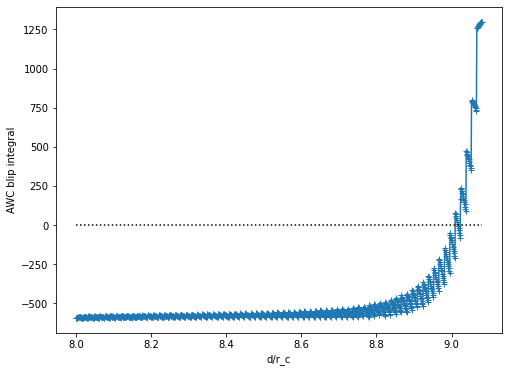

d where integral vanish: 9.009429429430243


In [5]:
fs = np.linspace(8, 9.08, 1000) # d space 
awc = [awc_integral(f, beta) for f in fs]

#sol = optimize.root(awc_integral, args=(beta))
#if sol.success:
#    print("Solution found successfully!")
#else:
#    print("Solution not found.")
#print('d where integral vanish:', sol.x)
plt.figure(figsize=(8, 6))
plt.plot(fs, awc, '-+')
#plt.plot(sol.x, 0, 'o')
plt.plot([min(fs), max(fs)], [0, 0],'k:')
plt.xlabel('d/r_c')
plt.ylabel('AWC blip integral')
plt.show()
awc = [safe_awc_integral(f, beta) for f in fs]
root = brentq(lambda f: safe_awc_integral(f,beta), 8, 9.08)
#sol = optimize.root(awc_integral, args=(beta))
#if sol.success:
#    print("Solution found successfully!")
#else:
#    print("Solution not found.")
print('d where integral vanish:', root)

* Check the third shell implementation

considered


/var/folders/60/sh47svf90t56m85qnl3kd58m0000gn/T/ipykernel_6000/3914331705.py:37: RuntimeWarning: divide by zero encountered in divide
  y += (Chang_H1/x)*(1-np.heaviside(1-x, 0.5))
/var/folders/60/sh47svf90t56m85qnl3kd58m0000gn/T/ipykernel_6000/3914331705.py:37: RuntimeWarning: invalid value encountered in multiply
  y += (Chang_H1/x)*(1-np.heaviside(1-x, 0.5))
/var/folders/60/sh47svf90t56m85qnl3kd58m0000gn/T/ipykernel_6000/3914331705.py:64: RuntimeWarning: divide by zero encountered in divide
  y += (Chang_H2/x)*(1 - np.heaviside(2-x, 0.5))
/var/folders/60/sh47svf90t56m85qnl3kd58m0000gn/T/ipykernel_6000/3914331705.py:64: RuntimeWarning: invalid value encountered in multiply
  y += (Chang_H2/x)*(1 - np.heaviside(2-x, 0.5))


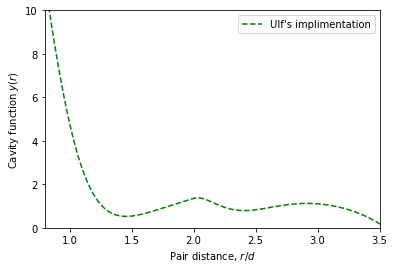

In [57]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import optimize
import sympy
eta=0.4908738521234051
def get_cavity_function(r, d, eta=0.4908738521234051):
    from numpy import exp, cos, sin
    x = r / d

    # Zeroth shell
    lambda_1 = (1+2*eta)**2/(1-eta)**4
    lambda_2 = -(2+eta)**2/(4*(1-eta)**4)
 
    x = r/d
    c = (-lambda_1-6*eta*lambda_2*x-0.5*eta*lambda_1*x**3)*np.heaviside(1-x, 0.5)
    y = -c
    
    # First shell
    f = 3 + 3*eta-eta**2
    arg = (2*eta**4/f**2+1)**0.5
    y_plus = (2*eta*f)**(1/3)*(arg+1)**(1/3)
    y_minus = (2*eta*f)**(1/3)*(arg-1)**(1/3)
    z_d = y_plus - y_minus
    z_s = y_plus + y_minus
    A = (-2*eta+z_d)/(1-eta)
    B = (-2*eta-0.5*z_d)/(1-eta)
    C = 3**(1/2)*z_s/(2*(1-eta))
    a_1 = -2*eta*(1-eta-3*eta**2) + (1-3*eta-4*eta**2)*z_d + (1+eta/2)*z_d**2
    a_1 = a_1/(3*(2*eta**2+z_d**2)*(1-eta)**2)
    a_2 = eta*(2+4*eta-3*eta**2)-(1-3*eta-4*eta**2)*z_d+2*(1+eta/2)*z_d**2
    a_2 = a_2/(3*(2*eta**2+z_d**2)*(1-eta)**2)
    a_3 = (1-3*eta-4*eta**2)*(4*eta**2+z_d**2)+eta*(2-5*eta**2)*z_d
    a_3 = a_3/(3**(1/2)*z_s*(2*eta**2+z_d**2)*(1-eta)**2)

    Chang_H1 = (a_1*exp(A*(x-1))+a_2*exp(B*(x-1))*cos(C*(x-1))+a_3*exp(B*(x-1))*sin(C*(x-1)))
    y += (Chang_H1/x)*(1-np.heaviside(1-x, 0.5))

    # Second shell
    f = 3 + 3 * eta - eta ** 2
    arg = (2 * eta ** 4 / f ** 2 + 1) ** 0.5
    y_plus = (2 * eta * f) ** (1 / 3) * (arg + 1) ** (1 / 3)
    y_minus = (2 * eta * f) ** (1 / 3) * (arg - 1) ** (1 / 3)
    z_d = y_plus - y_minus
    z_s = y_plus + y_minus
    A = (-2 * eta + z_d) / (1 - eta)
    B = (-2 * eta - 0.5 * z_d) / (1 - eta)
    C = 3 ** (1 / 2) * z_s / (2 * (1 - eta))
    a_1 = -2 * eta * (1 - eta - 3 * eta ** 2) + (1 - 3 * eta - 4 * eta ** 2) * z_d + (1 + eta / 2) * z_d ** 2
    a_1 /= (3 * (2 * eta ** 2 + z_d ** 2) * (1 - eta) ** 2)
    a_2 = eta * (2 + 4 * eta - 3 * eta ** 2) - (1 - 3 * eta - 4 * eta ** 2) * z_d + 2 * (1 + eta / 2) * z_d ** 2
    a_2 /= (3 * (2 * eta ** 2 + z_d ** 2) * (1 - eta) ** 2)
    a_3 = (1 - 3 * eta - 4 * eta ** 2) * (4 * eta ** 2 + z_d ** 2) + eta * (2 - 5 * eta ** 2) * z_d
    a_3 /= (3 ** (1 / 2) * z_s * (2 * eta ** 2 + z_d ** 2) * (1 - eta) ** 2)
    b_1 = -4/3*eta*((2*eta**2-z_d**2)*(1-6*eta-3*eta**2+20*eta**3+15*eta**4)+z_d*eta*(16+24*eta-21*eta**2-13*eta**3+21*eta**4))/((2*eta**2+z_d**2)**3*(1-eta)**2)
    b_2 = -1.0*b_1
    b_3 = 8*(3**(1/2))*eta**2*((4*eta**2+z_d**2)*(2-10*eta-24*eta**2+30*eta**3+79*eta**4+21*eta**5-17*eta**6)+2*z_d*eta*(16+40*eta-eta**2-50*eta**3+11*eta**4+52*eta**5+13*eta**6))/(z_s**3*(2*eta**2+z_d**2)**3*(1-eta)**2)
    b_4 = -2/3*eta*(2*eta*(10+28*eta+21*eta**2-13*eta**3-19*eta**4)+z_d*(2-12*eta-18*eta**2+28*eta**3+27*eta**4)+z_d**2*(4-6*eta-18*eta**2-7*eta**3))/((2*eta**2+z_d**2)**2*(1-eta)**3)
    b_5 = -4/3*eta**2*(4*(6-30*eta-82*eta**2+58*eta**3+222*eta**4+94*eta**5-25*eta**6)-z_d*(24-10*eta-164*eta**2-156*eta**3+22*eta**4+41*eta**5)-z_d**2*(10+32*eta+15*eta**2-31*eta**3-26*eta**4))/(z_s**2*(2*eta**2+z_d**2)**2*(1-eta)**3)
    b_6 = 4/(3)**(1/2)*eta**2*(24-10*eta-164*eta**2-156*eta**3+22*eta**4+41*eta**5-z_d*(10+32*eta+15*eta**2-31*eta**3-26*eta**4))/(z_s*(2*eta**2+z_d**2)**2*(1-eta)**3)
    Chang_01 =  b_1+b_2
    Chang_H2 = (b_1*exp(A*(x-2))+b_2*exp(B*(x-2))*cos(C*(x-2))+b_3*exp(B*(x-2))*sin(C*(x-2))+b_4*(x-2)*exp(A*(x-2))+b_5*(x-2)*exp(B*(x-2))*cos(C*(x-2))+b_6*(x-2)*exp(B*(x-2))*sin(C*(x-2)))
    #correction = (Chang_0-Chang_01)*0.5
    y += (Chang_H2/x)*(1 - np.heaviside(2-x, 0.5))
    print("considered")
    return y


# Test implimentation of cavity function
#   by comparing to fortran program by [Smith 2008]
plt.figure()
#plt.plot(r, y_from_fortran_program['y'], 'k-', label='from [Smith 2008]')
r=np.linspace(0,4.0,1000)
plt.plot(r, get_cavity_function(r, 1.0, eta), 'g--', label="Ulf's implimentation")
plt.xlim(0.8, 3.5)
plt.ylim(0, 10)
plt.xlabel('Pair distance, $r/d$')
plt.ylabel('Cavity function $y(r)$')
plt.legend()
plt.show()